### Transformer Encoder for Sentiment Analysis: IMDB Movie Reviews
Source: https://github.com/fchollet/deep-learning-with-python-notebooks/blob/master/chapter11_part03_transformer.ipynb

**Getting the data**

In [1]:
!curl -O https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
!tar -xf aclImdb_v1.tar.gz
!rm -r aclImdb/train/unsup

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 80.2M  100 80.2M    0     0  9554k      0  0:00:08  0:00:08 --:--:-- 7356k


**Preparing the data**

In [2]:
import os, pathlib, shutil, random
from tensorflow import keras
batch_size = 32
base_dir = pathlib.Path("aclImdb")
val_dir = base_dir / "val"
train_dir = base_dir / "train"
for category in ("neg", "pos"):
    os.makedirs(val_dir / category)
    files = os.listdir(train_dir / category)
    random.Random(1337).shuffle(files)
    num_val_samples = int(0.2 * len(files))
    val_files = files[-num_val_samples:]
    for fname in val_files:
        shutil.move(train_dir / category / fname,
                    val_dir / category / fname)

train_ds = keras.utils.text_dataset_from_directory(
    "aclImdb/train", batch_size=batch_size
)
val_ds = keras.utils.text_dataset_from_directory(
    "aclImdb/val", batch_size=batch_size
)
test_ds = keras.utils.text_dataset_from_directory(
    "aclImdb/test", batch_size=batch_size
)
text_only_train_ds = train_ds.map(lambda x, y: x)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.


**Vectorizing the data**

In [3]:
from tensorflow.keras import layers

max_length = 600
max_tokens = 20000
text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=max_length,
)
text_vectorization.adapt(text_only_train_ds)

int_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)
int_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)
int_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)

**Transformer encoder implemented as a subclassed `Layer`**

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim)
        self.dense_proj = keras.Sequential(
            [layers.Dense(dense_dim, activation="relu"),
             layers.Dense(embed_dim),]
        )
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()

    def call(self, inputs, mask=None):
        if mask is not None:
            mask = mask[:, tf.newaxis, :]
        attention_output = self.attention(
            inputs, inputs, attention_mask=mask)
        proj_input = self.layernorm_1(inputs + attention_output)
        proj_output = self.dense_proj(proj_input)
        return self.layernorm_2(proj_input + proj_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dense_dim": self.dense_dim,
        })
        return config

**Using the Transformer encoder for text classification**

In [5]:
vocab_size = 20000
#embed_dim = 256
embed_dim = 32
num_heads = 2
dense_dim = 32

inputs = keras.Input(shape=(None,), dtype="int64")
x = layers.Embedding(vocab_size, embed_dim)(inputs)
x = TransformerEncoder(embed_dim, dense_dim, num_heads)(x)
x = layers.GlobalMaxPooling1D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 32)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, None, 32)       │        10,656 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,689 (2.48 MB)

 Trainable params: 650,689 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

**Training and evaluating the Transformer encoder based model**

In [6]:
callbacks = [
    keras.callbacks.ModelCheckpoint("transformer_encoder.keras",
                                    save_best_only=True)
]
#model.fit(int_train_ds, validation_data=int_val_ds, epochs=20, callbacks=callbacks)
model.fit(int_train_ds, validation_data=int_val_ds, epochs=2, callbacks=callbacks)
model = keras.models.load_model(
    "transformer_encoder.keras",
    custom_objects={"TransformerEncoder": TransformerEncoder})
print(f"Test acc: {model.evaluate(int_test_ds)[1]:.3f}")

Epoch 1/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 87s 126ms/step - accuracy: 0.6646 - loss: 0.6050 - val_accuracy: 0.7922 - val_loss: 0.4518
Epoch 2/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 125ms/step - accuracy: 0.7876 - loss: 0.4581 - val_accuracy: 0.8206 - val_loss: 0.3985


/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'transformer_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8234 - loss: 0.3956
Test acc: 0.823


#### Using positional encoding to re-inject order information

**Implementing positional embedding as a subclassed layer**

In [7]:
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, input_dim, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = layers.Embedding(
            input_dim=input_dim, output_dim=output_dim)
        self.position_embeddings = layers.Embedding(
            input_dim=sequence_length, output_dim=output_dim)
        self.sequence_length = sequence_length
        self.input_dim = input_dim
        self.output_dim = output_dim

    def call(self, inputs):
        length = tf.shape(inputs)[-1]
        positions = tf.range(start=0, limit=length, delta=1)
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions

    def compute_mask(self, inputs, mask=None):
        #return tf.math.not_equal(inputs, 0)
        #return tf.keras.backend.not_equal(inputs, 0)
        # Use Keras layers for masking operations
        mask = layers.Lambda(lambda x: tf.keras.backend.not_equal(x, 0))(inputs)
        return mask

    def get_config(self):
        config = super().get_config()
        config.update({
            "output_dim": self.output_dim,
            "sequence_length": self.sequence_length,
            "input_dim": self.input_dim,
        })
        return config

#### Putting it all together: A text-classification Transformer

**Combining the Transformer encoder with positional embedding**

In [8]:
vocab_size = 20000
sequence_length = 600
#embed_dim = 256
embed_dim = 32
num_heads = 2
dense_dim = 32

inputs = keras.Input(shape=(None,), dtype="int64")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(inputs)
x = TransformerEncoder(embed_dim, dense_dim, num_heads)(x)
x = layers.GlobalMaxPooling1D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.summary()

callbacks = [
    keras.callbacks.ModelCheckpoint("full_transformer_encoder.keras",
                                    save_best_only=True)
]
#model.fit(int_train_ds, validation_data=int_val_ds, epochs=20, callbacks=callbacks)
model.fit(int_train_ds, validation_data=int_val_ds, epochs=2, callbacks=callbacks)
#model = keras.models.load_model(
#    "full_transformer_encoder.keras",
#    custom_objects={"TransformerEncoder": TransformerEncoder,
#                    "PositionalEmbedding": PositionalEmbedding},
#    safe_mode=False # Add this line to allow loading models with lambda layers
#)
print(f"Test acc: {model.evaluate(int_test_ds)[1]:.3f}")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'transformer_encoder_1' (of type TransformerEncoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 32)  │    659,200 │ input_layer_3[0]… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, None)      │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, None, 32)  │     10,656 │ positional_embed… │
│ (TransformerEncode… │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ transformer_enco… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32)        │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         33 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 669,889 (2.56 MB)

 Trainable params: 669,889 (2.56 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 75ms/step - accuracy: 0.6984 - loss: 0.5767 - val_accuracy: 0.8410 - val_loss: 0.3564
Epoch 2/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 76ms/step - accuracy: 0.8735 - loss: 0.3100 - val_accuracy: 0.8632 - val_loss: 0.3204
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8690 - loss: 0.3006
Test acc: 0.869


In [9]:
!date; ls -lh

Thu Sep 17 07:05:24 AM UTC 2026
total 91M
drwxr-xr-x 5 7297 ubuntu 4.0K Sep 17 07:00 aclImdb
-rw-r--r-- 1 root root    81M Sep 17 07:00 aclImdb_v1.tar.gz
-rw-r--r-- 1 root root   5.2M Sep 17 07:05 full_transformer_encoder.keras
drwxr-xr-x 1 root root   4.0K Sep  4 13:32 sample_data
-rw-r--r-- 1 root root   5.1M Sep 17 07:03 transformer_encoder.keras


# CNN followed by Transformer Encoder for Cifar-10 (to be completed)

### CNN followed by Transformer Encoder for Cifar-10

A small CNN turns each 32x32 image into an 8x8 grid of feature maps, which is
flattened into 64 tokens and passed through two `TransformerEncoder` layers.

The `PositionalEmbedding` from the IMDB model is not reused here. Its
`compute_mask()` tests tokens against 0, which only makes sense for word ids,
so an image version is defined below instead.


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2215s 13us/step
X_train (45000, 32, 32, 3) X_valid (5000, 32, 32, 3) X_test (10000, 32, 32, 3)


Model: "cifar10CnnTransEncB"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 810,346 (3.09 MB)

 Trainable params: 809,706 (3.09 MB)

 Non-trainable params: 640 (2.50 KB)


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/60

Epoch 1: val_accuracy improved from None to 0.44880, saving model to cifar10CnnTransEncB.keras

Epoch 1: finished saving model to cifar10CnnTransEncB.keras
352/352 - 35s - 99ms/step - accuracy: 0.3965 - loss: 1.7103 - val_accuracy: 0.4488 - val_loss: 1.6441 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.001.
Epoch 2/60

Epoch 2: val_accuracy improved from 0.44880 to 0.53640, saving model to cifar10CnnTransEncB.keras

Epoch 2: finished saving model to cifar10CnnTransEncB.keras
352/352 - 21s - 60ms/step - accuracy: 0.5256 - loss: 1.3797 - val_accuracy: 0.5364 - val_loss: 1.4815 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.001.
Epoch 3/60

Epoch 3: val_accuracy improved from 0.53640 to 0.60340, saving model to cifar10CnnTransEncB.keras

Epoch 3: finished saving model to cifar10CnnTransEncB.keras
352/352 - 20s - 58ms/step - accuracy: 0.5877 -

/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'encoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'encoder_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Best checkpoint [loss, accuracy]: [0.561030924320221, 0.8450000286102295]
Best accuracy (on testing dataset): 84.50%
              precision    recall  f1-score   support

    airplane     0.8580    0.8640    0.8610      1000
  automobile     0.9132    0.9470    0.9298      1000
        bird     0.8222    0.7910    0.8063      1000
         cat     0.7855    0.6410    0.7059      1000
        deer     0.8408    0.8080    0.8241      1000
         dog     0.8556    0.7290    0.7873      1000
        frog     0.7242    0.9610    0.8260      1000
       horse     0.8882    0.8740    0.8810      1000
        ship     0.9165    0.9110    0.9137      1000
       truck     0.8717    0.9240    0.8971      1000

    accuracy                         0.8450     10000
   macro avg     0.8476    0.8450    0.8432     10000
weighted avg     0.8476    0.8450    0.8432     10000

[[864  12  32   8   7   0   9   6  37  25]
 [  4 947   1   0   0   0   2   0   3  43]
 [ 26   4 791  17  29  28  71  19   5 

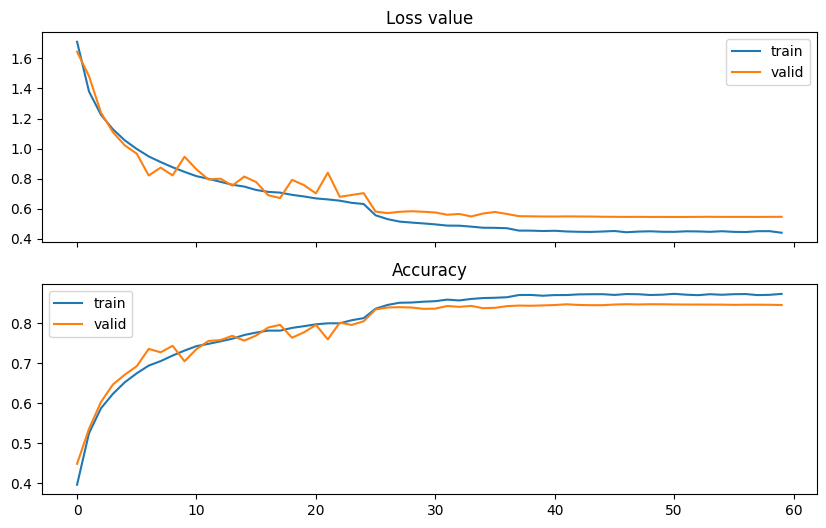

In [10]:
# CNN + transformer encoder for Cifar-10. The cells above only load
# text, so the CIFAR-10 pipeline is built here; TransformerEncoder is
# reused from the cell above.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.metrics as metrics
from tensorflow.keras import layers
from tensorflow.keras.callbacks import (ModelCheckpoint, CSVLogger,
                                        LearningRateScheduler)
from tensorflow.keras.utils import to_categorical

(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_mean = X_train.mean(axis=0, keepdims=True)
X_std  = X_train.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test  = (X_test  - X_mean) / X_std

NUM_CLASSES = 10
y_train_encoded = to_categorical(y_train, num_classes=NUM_CLASSES)
y_valid_encoded = to_categorical(y_valid, num_classes=NUM_CLASSES)
y_test_encoded  = to_categorical(y_test,  num_classes=NUM_CLASSES)

labelname = ['airplane', 'automobile', 'bird', 'cat', 'deer',
             'dog', 'frog', 'horse', 'ship', 'truck']

print("X_train", X_train.shape, "X_valid", X_valid.shape, "X_test", X_test.shape)

# Uppercase so these don't collide with batch_size / embed_dim /
# num_heads / dense_dim from the IMDB cells
IMG_SHAPE    = (32, 32, 3)
BATCH_SIZE   = 128
EPOCHS       = 60
SEED         = 29
WD           = 1e-4
ROTATION_DEG = 20

keras.utils.set_random_seed(SEED)


# Keras 3 replacement for ImageDataGenerator, which is deprecated
def augmentation_layers():
    return [
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomTranslation(0.10, 0.10, fill_mode="reflect", seed=SEED),
        # RandomRotation takes a fraction of a turn, not degrees
        layers.RandomRotation(ROTATION_DEG / 360.0,
                              fill_mode="reflect", seed=SEED),
    ]


def lr_schedule(epoch, lr):
    frac = epoch / float(EPOCHS)
    if   frac > 0.80: return 5e-7
    elif frac > 0.70: return 1e-6
    elif frac > 0.60: return 1e-5
    elif frac > 0.40: return 1e-4
    return 1e-3


# Position embedding over the patch grid. No compute_mask(): the tokens
# are feature maps, not word ids.
class ImagePositionalEmbedding(layers.Layer):
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.embed_dim = embed_dim
        self.position_embeddings = layers.Embedding(
            input_dim=num_patches, output_dim=embed_dim)

    def build(self, input_shape):
        self.position_embeddings.build((None, self.num_patches))
        super().build(input_shape)

    def call(self, inputs):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return inputs + self.position_embeddings(positions)

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches,
                       "embed_dim": self.embed_dim})
        return config


# tf.keras here has no .saving, so load the custom layers by name
CUSTOM_OBJECTS = {"TransformerEncoder": TransformerEncoder,
                  "ImagePositionalEmbedding": ImagePositionalEmbedding}

CNN_WIDTH  = 128
EMBED_DIM  = 128
DENSE_DIM  = 256
NUM_HEADS  = 4
DEPTH      = 2
NUM_TOKENS = 64          # 8 x 8 grid

modelname = "cifar10CnnTransEncB"

model = keras.Sequential([
    layers.Input(shape=IMG_SHAPE),
    *augmentation_layers(),

    # CNN feature extractor: 32 -> 16 -> 8
    layers.Conv2D(32, (3, 3), padding='same', use_bias=False,
                  kernel_initializer='he_normal',
                  kernel_regularizer=keras.regularizers.l2(WD)),
    layers.BatchNormalization(), layers.Activation('relu'),
    layers.Conv2D(32, (3, 3), padding='same', use_bias=False,
                  kernel_initializer='he_normal',
                  kernel_regularizer=keras.regularizers.l2(WD)),
    layers.BatchNormalization(), layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),              # 16 x 16
    layers.Dropout(0.2),

    layers.Conv2D(64, (3, 3), padding='same', use_bias=False,
                  kernel_initializer='he_normal',
                  kernel_regularizer=keras.regularizers.l2(WD)),
    layers.BatchNormalization(), layers.Activation('relu'),
    layers.Conv2D(64, (3, 3), padding='same', use_bias=False,
                  kernel_initializer='he_normal',
                  kernel_regularizer=keras.regularizers.l2(WD)),
    layers.BatchNormalization(), layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),              # 8 x 8
    layers.Dropout(0.3),

    layers.Conv2D(CNN_WIDTH, (3, 3), padding='same', use_bias=False,
                  kernel_initializer='he_normal',
                  kernel_regularizer=keras.regularizers.l2(WD)),
    layers.BatchNormalization(), layers.Activation('relu'),   # 8 x 8 x 128

    # every spatial position becomes one token
    layers.Reshape((NUM_TOKENS, EMBED_DIM), name='to_tokens'),
    ImagePositionalEmbedding(NUM_TOKENS, EMBED_DIM, name='pos_embed'),

    TransformerEncoder(EMBED_DIM, DENSE_DIM, NUM_HEADS, name='encoder_1'),
    TransformerEncoder(EMBED_DIM, DENSE_DIM, NUM_HEADS, name='encoder_2'),

    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax',
                 kernel_initializer='he_normal'),
], name=modelname)

model.summary()

model.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              metrics=["accuracy"])

# lr_sched must come first: it is what logs learning_rate for the CSV
checkpoint = ModelCheckpoint(modelname + ".keras", monitor='val_accuracy',
                             verbose=1, save_best_only=True, mode='max')
lr_sched   = LearningRateScheduler(lr_schedule, verbose=1)
csv_logger = CSVLogger(modelname + '.csv')

history = model.fit(X_train, y_train_encoded, epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_data=(X_valid, y_valid_encoded),
                    callbacks=[checkpoint, lr_sched, csv_logger], verbose=2)

model = keras.models.load_model(modelname + ".keras",
                                custom_objects=CUSTOM_OBJECTS)
score = model.evaluate(X_test, y_test_encoded, verbose=0)
print("Best checkpoint [loss, accuracy]:", score)

y_pred  = model.predict(X_test, verbose=0)
predout = np.argmax(y_pred, axis=1)
testout = np.argmax(y_test_encoded, axis=1)
print("Best accuracy (on testing dataset): %.2f%%" %
      (metrics.accuracy_score(testout, predout) * 100))
print(metrics.classification_report(testout, predout, target_names=labelname,
                                    digits=4, zero_division=0))
print(metrics.confusion_matrix(testout, predout))

records = pd.read_csv(modelname + '.csv')
plt.figure(figsize=(10, 6))
plt.subplot(211)
plt.plot(records['loss'],     label='train')
plt.plot(records['val_loss'], label='valid')
plt.title('Loss value', fontsize=12)
plt.legend()
ax = plt.gca()
ax.set_xticklabels([])
plt.subplot(212)
plt.plot(records['accuracy'],     label='train')
plt.plot(records['val_accuracy'], label='valid')
plt.title('Accuracy', fontsize=12)
plt.legend()
plt.show()


#### With and without positional embedding

Test accuracy of the two IMDB models above, 2 epochs each:

| Model | Test accuracy |
| --- | --- |
| `TransformerEncoder` alone | 0.823 |
| `PositionalEmbedding` + `TransformerEncoder` | 0.869 |

Self-attention is permutation invariant: it sums each token's scores against
every other token, so shuffling the words gives the same result. Word order
has to be added back in, and a learned embedding per position recovers about
4.6 points without changing the attention layer itself.
